In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import importlib

from models import PINN, FNN, FourierEmbedding, device, dtype
from sklearn.model_selection import train_test_split

### Data Genration and Second Derivative Definition

In [2]:
def f(x):
    return 2 + 1/ (1 + 10 * x**2) * torch.sin(5 * x)  # define the function here

def target_physics(x):
        # First derivative
    f_prime = torch.autograd.grad(f(x).sum(), x, create_graph=True)[0]
    # print(f"f'(x)  = {f_prime.item()}")   # 3x² + 4x = 27 + 12 = 39
    # Second derivative
    f_double_prime = torch.autograd.grad(f_prime.sum(), x)[0]
    
    return f_double_prime

In [3]:
f(torch.tensor(-10))

tensor(2.0003)

In [4]:
def generate_data(n_samples, a=-1, b=1):
    x = np.random.uniform(a, b, n_samples)
    x_tensor = torch.tensor(x, dtype=dtype, device=device).unsqueeze(1)
    y_tensor = f(x_tensor)
    return x_tensor, y_tensor
# # Model the target physics
# def target_physics(x):
#     return -2 * torch.ones_like(x)

# Generate data with the function defined above
x_gen, y_gen = generate_data(10000, a=-4, b=1)
x_train, x_val, y_train, y_val = train_test_split(x_gen, y_gen, test_size=0.2, random_state=42)

In [5]:
# importlib.reload(FourierEmbedding)
embed = FourierEmbedding(
    input_dim=1, 
    embed_dim=1, 
    scale=10.0,
    learnable=True, 
    l1_strength=1e-4, 
    l1_start_epoch=2000
).to(device)

model_1 = PINN([1, 32, 256, 1], activation=torch.nn.Tanh, embedding=embed).to(device)
train_loss_1, val_loss_1 = model_1.train_model(
    x_train, y_train, 
    epochs=1500, 
    lr=1e-3, 
    track_loss=True,
    x_val=x_val, 
    y_val=y_val,
    lr_change=[1000, 1e-4], 
    target_physics=target_physics,
    lambda_phy=1,
    lambda_data=2.5
)

Training Epoch: 100%|██████████| 1500/1500 [00:22<00:00, 67.57it/s]


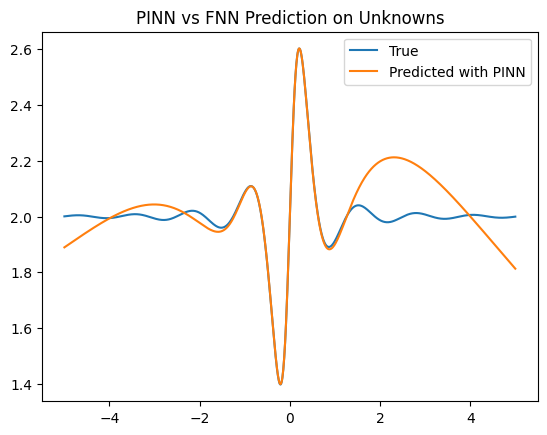

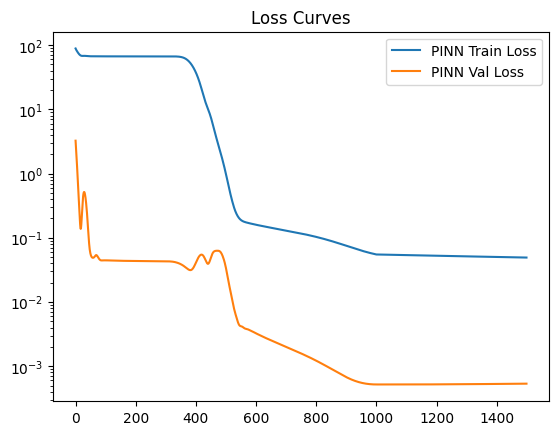

In [6]:

x_test = torch.linspace(-5, 5, 1000).unsqueeze(1).to(device)
y_true = f(x_test)

y_pred_1 = model_1.predict(x_test).cpu().numpy().flatten()
# y_pred_2 = model_2.predict(x_test).cpu().numpy().flatten()
test_loss_1 = np.mean((y_pred_1 - y_true.cpu().numpy().flatten()) ** 2)
# test_loss_2 = np.mean((y_pred_2 - y_true.cpu().numpy().flatten()) ** 2)

x_test = x_test.cpu().numpy().flatten()
y_true = y_true.cpu().numpy().flatten()

plt.plot(x_test, y_true, label='True')
plt.plot(x_test, y_pred_1, label='Predicted with PINN')
# plt.plot(x_test, y_pred_2, label='Predicted with FNN')
plt.title('PINN vs FNN Prediction on Unknowns')
plt.legend()
# textstr = f'PINN Val Loss: {val_loss_1[-1]:.3e} - Test Loss: {test_loss_1:.3e}\n FNN Val Loss: {val_loss_2[-1]:.3e} - Test Loss: {test_loss_2:.3e}'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
# plt.text(0.5, 0.1, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center', bbox=props)
plt.show()

plt.figure()
plt.semilogy(train_loss_1, label='PINN Train Loss')
plt.semilogy(val_loss_1, label='PINN Val Loss')
# plt.semilogy(train_loss_2, '--', label='FNN Train Loss')
# plt.semilogy(val_loss_2, '--', label='FNN Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

quasi newton since you use the hessian avoids spikes because it reades the curvature

adaptive scaling of lambda depending on domain

### perchè la validation loss è violentemente piu bassa della training?